# 03 — ResNet-18 Classifier Training (The Expert)
,

ResNet-18 is modified for CIFAR-100 (32x32) by replacing the large 7x7 stride-2 stem with a 3x3 stride-1 convolution and removing maxpool. This avoids aggressive spatial downsampling on small images.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import yaml
from sklearn.metrics import confusion_matrix
from torchvision.models import ResNet18_Weights, resnet18

sys.path.append(str(Path('..').resolve()))
torch.manual_seed(42)
np.random.seed(42)

In [2]:
from src.classifier import get_classifier

with open('../configs/config.yaml', 'r', encoding='utf-8') as file:
    config = yaml.safe_load(file)

original_resnet = resnet18(weights=ResNet18_Weights.DEFAULT)
classifier = get_classifier(config)

print('Original conv1 :', original_resnet.conv1)
print('Modified conv1 :', classifier.backbone.conv1)
print('Original maxpool:', original_resnet.maxpool)
print('Modified maxpool:', classifier.backbone.maxpool)
print('Trainable parameters:', f'{classifier.get_trainable_params():,}')

Original conv1 : Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
Modified conv1 : Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
Original maxpool: MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
Modified maxpool: Identity()
Trainable parameters: 11,325,860


In [3]:
dummy = torch.randn(4, 3, 32, 32)
logits = classifier(dummy)
print('Output shape:', tuple(logits.shape))

Output shape: (4, 100)


In [4]:
# Phase 1 setup: frozen backbone, FC head only.
classifier.freeze_backbone()
phase1_optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, classifier.parameters()),
    lr=0.001,
    weight_decay=1e-4,
)
print('Phase 1 epochs:', 10)
print('Phase 1 trainable params:', f'{classifier.get_trainable_params():,}')
print('Phase 1 optimizer LR:', phase1_optimizer.param_groups[0]['lr'])

Phase 1 epochs: 10
Phase 1 trainable params: 158,756
Phase 1 optimizer LR: 0.001


In [5]:
from src.train_classifier import train_classifier_model

# Runs both phases: 10 epochs frozen + 50 epochs full fine-tuning.
history = train_classifier_model('../configs/config.yaml')
print('Training history keys:', history.keys())

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


Phase 1 | Epoch 1/10 | Train Loss: 4.0836 | Train Acc: 0.0791 | Val Loss: 3.5574 | Val Acc (avg): 0.1637 | Val Clean: 0.1742 | Val Healed: 0.1531 | Val Top5: 0.4165 | LR: 0.001000


Phase 1 | Epoch 2/10 | Train Loss: 3.6035 | Train Acc: 0.1483 | Val Loss: 3.2650 | Val Acc (avg): 0.2127 | Val Clean: 0.2342 | Val Healed: 0.1913 | Val Top5: 0.4857 | LR: 0.001000


Phase 1 | Epoch 3/10 | Train Loss: 3.4605 | Train Acc: 0.1706 | Val Loss: 3.1703 | Val Acc (avg): 0.2336 | Val Clean: 0.2633 | Val Healed: 0.2039 | Val Top5: 0.5152 | LR: 0.001000


Phase 1 | Epoch 4/10 | Train Loss: 3.3739 | Train Acc: 0.1857 | Val Loss: 3.0935 | Val Acc (avg): 0.2473 | Val Clean: 0.2767 | Val Healed: 0.2180 | Val Top5: 0.5322 | LR: 0.001000


...

Phase 2 | Epoch 46/50 | Train Loss: 0.3832 | Train Acc: 0.8869 | Val Loss: 1.4833 | Val Acc (avg): 0.6803 | Val Clean: 0.7449 | Val Healed: 0.6157 | Val Top5: 0.8826 | LR: 0.000002


Phase 2 | Epoch 47/50 | Train Loss: 0.3788 | Train Acc: 0.8888 | Val Loss: 1.5153 | Val Acc (avg): 0.6762 | Val Clean: 0.7429 | Val Healed: 0.6096 | Val Top5: 0.8807 | LR: 0.000002


Phase 2 | Epoch 48/50 | Train Loss: 0.3846 | Train Acc: 0.8893 | Val Loss: 1.4955 | Val Acc (avg): 0.6770 | Val Clean: 0.7455 | Val Healed: 0.6086 | Val Top5: 0.8828 | LR: 0.000001


Phase 2 | Epoch 49/50 | Train Loss: 0.3733 | Train Acc: 0.8898 | Val Loss: 1.4874 | Val Acc (avg): 0.6787 | Val Clean: 0.7429 | Val Healed: 0.6145 | Val Top5: 0.8813 | LR: 0.000000


Phase 2 | Epoch 50/50 | Train Loss: 0.3794 | Train Acc: 0.8905 | Val Loss: 1.5000 | Val Acc (avg): 0.6780 | Val Clean: 0.7445 | Val Healed: 0.6116 | Val Top5: 0.8815 | LR: 0.000000
Best validation accuracy (avg clean/healed): 68.03%
Model saved: models/resnet_classifier.pth
Training history keys: dict_keys(['train_loss', 'val_loss', 'train_acc', 'val_acc', 'val_top5_acc'])


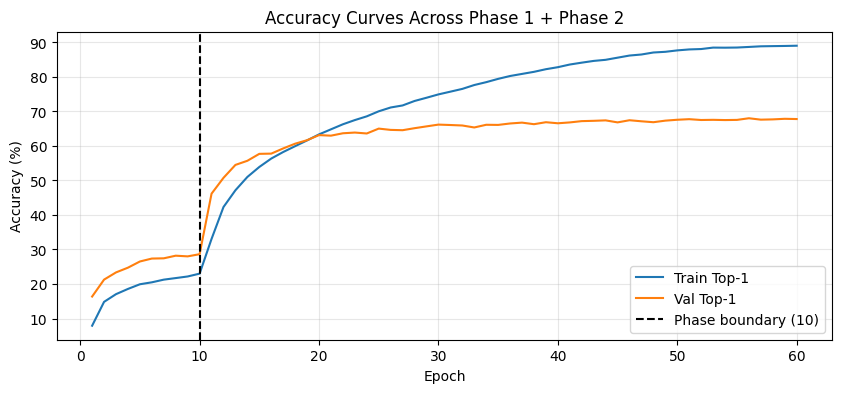

In [6]:
epochs = np.arange(1, len(history['train_acc']) + 1)

plt.figure(figsize=(10, 4))
plt.plot(epochs, np.array(history['train_acc']) * 100, label='Train Top-1')
plt.plot(epochs, np.array(history['val_acc']) * 100, label='Val Top-1')
plt.axvline(10, linestyle='--', color='black', label='Phase boundary (10)')
plt.title('Accuracy Curves Across Phase 1 + Phase 2')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

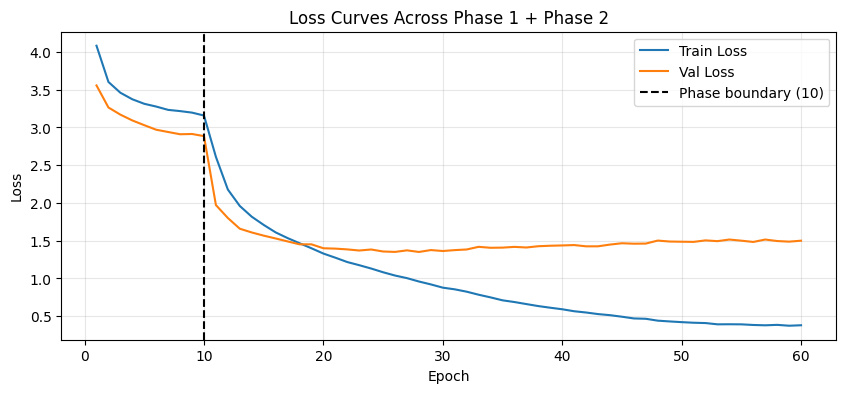

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(epochs, history['train_loss'], label='Train Loss')
plt.plot(epochs, history['val_loss'], label='Val Loss')
plt.axvline(10, linestyle='--', color='black', label='Phase boundary (10)')
plt.title('Loss Curves Across Phase 1 + Phase 2')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [10]:
from src.dataset import get_dataloaders

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

# Load the best weights saved during training
weights_path = '../models/resnet_classifier.pth'
if Path(weights_path).exists():
    print(f'Loading weights from {weights_path}...')
    classifier.load_state_dict(torch.load(weights_path, map_location=device))
else:
    print(f'WARNING: {weights_path} not found. Evaluation will use current (possibly uninitialized) weights.')

classifier = classifier.to(device).eval()
_, _, test_loader = get_dataloaders(config)

top1_correct = 0
top5_correct = 0
total = 0

with torch.no_grad():
    for _, clean, labels in test_loader:
        clean = clean.to(device)
        labels = labels.to(device)

        logits = classifier(clean)
        top1 = logits.argmax(dim=1)
        top5 = logits.topk(5, dim=1).indices

        top1_correct += int((top1 == labels).sum().item())
        top5_correct += int(top5.eq(labels.view(-1, 1)).any(dim=1).sum().item())
        total += labels.size(0)

top1_acc = 100.0 * top1_correct / max(total, 1)
top5_acc = 100.0 * top5_correct / max(total, 1)

print(f'Top-1 accuracy: {top1_acc:.2f}%')
print(f'Top-5 accuracy: {top5_acc:.2f}%')


Using device: cuda
Loading weights from ../models/resnet_classifier.pth...
Top-1 accuracy: 73.45%
Top-5 accuracy: 92.05%


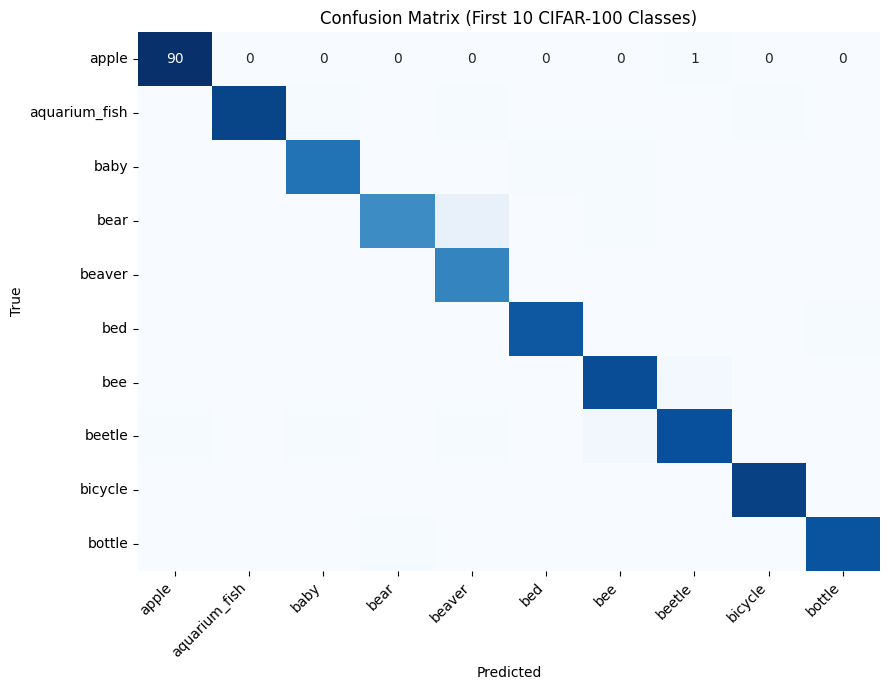

In [11]:
from src.dataset import CIFAR100_CLASSES

all_true = []
all_pred = []

with torch.no_grad():
    for _, clean, labels in test_loader:
        logits = classifier(clean.to(device))
        preds = logits.argmax(dim=1).cpu().numpy()
        labels_np = labels.numpy()

        mask = labels_np < 10
        all_true.extend(labels_np[mask].tolist())
        all_pred.extend(preds[mask].tolist())

cm = confusion_matrix(all_true, all_pred, labels=list(range(10)))

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (First 10 CIFAR-100 Classes)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(np.arange(10) + 0.5, [CIFAR100_CLASSES[i] for i in range(10)], rotation=45, ha='right')
plt.yticks(np.arange(10) + 0.5, [CIFAR100_CLASSES[i] for i in range(10)], rotation=0)
plt.tight_layout()
plt.show()

## Summary

The expert classifier uses a CIFAR-friendly ResNet-18 stem and two-phase transfer learning:

- Phase 1: Frozen backbone for stable head adaptation.
- Phase 2: Full fine-tuning with a lower learning rate.
- Evaluation includes clean Top-1/Top-5 metrics and a confusion matrix view.